## 1. Khởi tạo Môi trường và Kết nối Dữ liệu
- Khai báo các thư viện thiết yếu cho học sâu (PyTorch) và xử lý ảnh (OpenCV).
- Kết nối với Google Drive để nạp bộ dữ liệu GTSRB đã được chuẩn bị sẵn tại: https://drive.google.com/drive/folders/1Fo16-vGBoHUZ4xoQIc_9mCtzWEIqOwc_?usp=sharing

In [ ]:
import os
import cv2
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from google.colab import drive

# Kết nối Drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## 2. Cấu hình
Các thông số cấu hình được định nghĩa giúp dễ dàng tinh chỉnh trong quá trình thực nghiệm.
- IMG_SIZE (32x32): Kích thước chuẩn giúp cân bằng giữa độ chi tiết của ảnh và hiệu suất tính toán.
- BATCH_SIZE (64): Số lượng ảnh được đưa vào mạng trong một lần cập nhật trọng số.
- Thiết bị (Device): Tự động nhận diện và sử dụng GPU (CUDA) nếu có để tăng tốc huấn luyện.

In [ ]:
print("Đang copy dữ liệu từ Drive vào máy ảo Colab... (Sẽ mất khoảng 5-10 phút)")
!cp -r /content/drive/MyDrive/Data_BienGiaoThong /content/Data_Local
print(" Copy hoàn tất!")

Đang copy dữ liệu từ Drive vào máy ảo Colab... (Sẽ mất khoảng 5-10 phút)
 Copy hoàn tất!


In [ ]:
# --- config ---
DATA_DIR = '/content/Data_Local' # Đường dẫn đến Data
TRAIN_CSV = os.path.join(DATA_DIR, 'Train.csv')
TEST_CSV = os.path.join(DATA_DIR, 'Test.csv')
MODEL_DIR = '/content/drive/MyDrive/Data_BienGiaoThong/saved_models'

IMG_SIZE = 32
BATCH_SIZE = 64
EPOCHS = 20 # số vòng lặp
LEARNING_RATE = 0.001 # tốc độ học
NUM_CLASSES = 43 # số lớp gắn nhãn

os.makedirs(MODEL_DIR, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Đang chạy trên thiết bị: {device}")

 Đang chạy trên thiết bị: cuda


## 3. Xây dựng Luồng Nạp Dữ liệu (Data Loader)
Dữ liệu ảnh thô được đọc bằng OpenCV thông qua đường dẫn từ file `Train.csv`. Sau đó, ảnh được biến đổi theo các bước:
- Chuyển đổi hệ màu từ BGR (mặc định của OpenCV) sang RGB. (R: red, G: Green, B: Blue)
- Ép kích thước về 32x32 pixel.
- Chuyển thành dạng Tensor và chuẩn hóa giá trị điểm ảnh về khoảng [0, 1] (chia cho 255.0).
Tập dữ liệu sau đó được tự động chia thành 80% Train và 20% Validation.

In [ ]:
# --- data_loader ---
class GTSRBDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        # Chuyển HWC sang CHW và chuẩn hóa [0,1] (H: Heigh, W: Weigh, C: Channel: số lượng kênh màu)
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0
        label = torch.tensor(label, dtype=torch.long)
        return image, label

def load_from_csv(csv_path, img_dir, img_size):
    df = pd.read_csv(csv_path)
    images, labels = [], []
    for _, row in df.iterrows():
        img_path = os.path.join(img_dir, row['Path'])
        if os.path.exists(img_path):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # BGR -> RGB
            img = cv2.resize(img, (img_size, img_size)) # sửa ảnh = IMG_SIZE
            images.append(img)
            labels.append(row['ClassId'])
    return np.array(images), np.array(labels)

print(' Đang nạp ảnh từ Drive...')
X, y = load_from_csv(TRAIN_CSV, DATA_DIR, IMG_SIZE) # nạp ảnh từ train

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
) # chia 80% train, 20% val, stratify: cân bằng tỉ lệ phân loại dữ liệu giữa 2 tệp

train_loader = DataLoader(GTSRBDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True) # shuffle: trộn dữ liệu
val_loader = DataLoader(GTSRBDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)

print(f' Nạp xong! Tập Train: {len(X_train)} ảnh | Tập Val: {len(X_val)} ảnh')

 Đang nạp ảnh từ Drive...
 Nạp xong! Tập Train: 31367 ảnh | Tập Val: 7842 ảnh


## 4. Kiến trúc Mô hình CNN (Convolutional Neural Network)

Mô hình `SimpleCNN` được xây dựng từ đầu với các khối trích xuất đặc trưng nối tiếp nhau:
- Convolutional Layers (Conv2d): 3 lớp tích chập với số bộ lọc tăng dần (32 -> 64 -> 128) để quét và tìm kiếm từ các góc cạnh đơn giản đến các họa tiết phức tạp của biển báo.
- Max Pooling: Giảm một nửa kích thước không gian sau mỗi lớp Conv2d, giúp mô hình tập trung vào các chi tiết quan trọng nhất và giảm khối lượng tính toán.
- Fully Connected Layers (Linear): Lớp mạng nơ-ron dày đặc cuối cùng nhận nhiệm vụ phân loại ảnh vào 1 trong 43 lớp biển báo.
- Dropout (0.5): Kỹ thuật tắt ngẫu nhiên 50% nơ-ron trong quá trình huấn luyện nhằm ngăn chặn hiện tượng học vẹt (Overfitting).

In [ ]:
# --- model ---
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=43):
        super(SimpleCNN, self).__init__()
        # ma trận 3x3, viền ảnh (padding) = 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2) # gom vùng 2x2 lấy giá trị lớn nhất
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(128 * 4 * 4, 256) # 2048 -> 256
        self.fc2 = nn.Linear(256, num_classes) # 256 -> num_classes = 43
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # img_size = 32 / 2 = 16
        x = self.pool(F.relu(self.conv2(x))) # 16 -> 8
        x = self.pool(F.relu(self.conv3(x))) # 8 -> 4

        x = x.view(x.size(0), -1) # Dàn phẳng ma trận (Flatten) : 1D
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x # 1D : 43

# Khởi tạo mô hình và đẩy lên GPU
model = SimpleCNN(num_classes=NUM_CLASSES).to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=43, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


## 5. Quá trình Huấn luyện và Xác thực (Training)
- Mô hình sử dụng thuật toán tối ưu Adam để cập nhật trọng số và hàm suy hao CrossEntropyLoss đặc trưng cho bài toán phân loại đa nhãn.
- Sau mỗi vòng lặp (Epoch), mô hình sẽ tự động kiểm tra trên tập Validation để đánh giá khả năng Train của Epoch vừa rồi.

In [ ]:
# --- train ---
criterion = nn.CrossEntropyLoss() # tính toán loss
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE) # tinh chỉnh trọng số dựa vào loss

# Khởi tạo 4 danh sách để lưu lại lịch sử huấn luyện
history_train_loss, history_val_loss = [], []
history_train_acc, history_val_acc = [], []

print(" BẮT ĐẦU HUẤN LUYỆN... ")
for epoch in range(EPOCHS):
    # --- PHASE 1: TRAINING ---
    model.train() # chạy Dropout
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad() # xóa nháp
        outputs = model(images) # 1D : 43
        loss = criterion(outputs, labels) # đối chiếu sai lệch
        loss.backward() # tìm sai số nhất
        optimizer.step() # cập nhật trọng số

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1) # tìm số gần đúng nhất
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    # --- PHASE 2: VALIDATION ---
    model.eval() # tắt Dropout
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad(): # bỏ qua kiểm tra sai số
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    val_loss = val_loss / len(val_loader)

    # --- LƯU LỊCH SỬ TỪNG EPOCH ---
    history_train_loss.append(train_loss)
    history_val_loss.append(val_loss)
    history_train_acc.append(train_acc)
    history_val_acc.append(val_acc)

    print(f'Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.2f}%')

# Lưu mô hình
save_path = os.path.join(MODEL_DIR, 'simple_cnn_colab.pth')
torch.save(model.state_dict(), save_path)
print(f' Huấn luyện hoàn tất. Đã lưu mô hình tại: {save_path}')


 BẮT ĐẦU HUẤN LUYỆN... 
Epoch [1/20] | Train Loss: 2.4678 - Train Acc: 28.48% | Val Loss: 1.1890 - Val Acc: 60.16%
Epoch [2/20] | Train Loss: 0.9391 - Train Acc: 68.19% | Val Loss: 0.3752 - Val Acc: 89.90%
Epoch [3/20] | Train Loss: 0.4228 - Train Acc: 85.91% | Val Loss: 0.1502 - Val Acc: 95.68%
Epoch [4/20] | Train Loss: 0.2563 - Train Acc: 91.74% | Val Loss: 0.0880 - Val Acc: 97.65%
Epoch [5/20] | Train Loss: 0.1697 - Train Acc: 94.67% | Val Loss: 0.0673 - Val Acc: 98.21%
Epoch [6/20] | Train Loss: 0.1344 - Train Acc: 95.86% | Val Loss: 0.0553 - Val Acc: 98.46%
Epoch [7/20] | Train Loss: 0.1050 - Train Acc: 96.71% | Val Loss: 0.0425 - Val Acc: 98.94%
Epoch [8/20] | Train Loss: 0.0867 - Train Acc: 97.27% | Val Loss: 0.0377 - Val Acc: 99.16%
Epoch [9/20] | Train Loss: 0.0779 - Train Acc: 97.46% | Val Loss: 0.0367 - Val Acc: 99.15%
Epoch [10/20] | Train Loss: 0.0691 - Train Acc: 97.78% | Val Loss: 0.0284 - Val Acc: 99.17%
Epoch [11/20] | Train Loss: 0.0585 - Train Acc: 98.07% | Val Loss

📊 ĐANG VẼ BIỂU ĐỒ LEARNING CURVE...


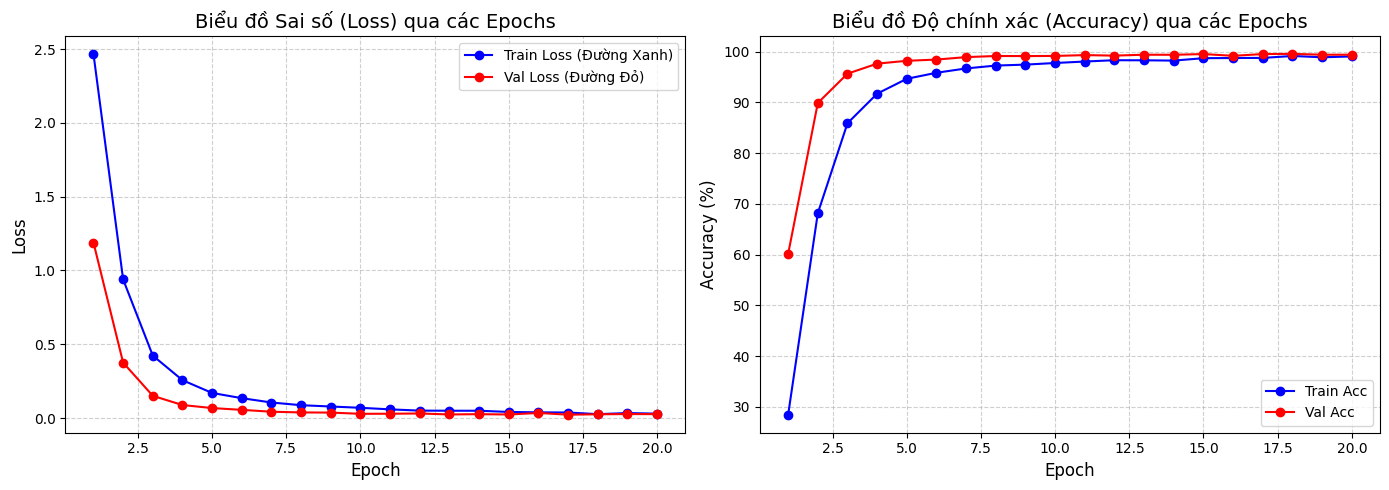

In [ ]:
# Gọi thư viện vẽ biểu đồ ra
import matplotlib.pyplot as plt

print("📊 ĐANG VẼ BIỂU ĐỒ LEARNING CURVE...")

# Lấy lại số lượng Epoch từ biến hệ thống
epochs_range = range(1, len(history_train_loss) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Biểu đồ Loss (Sai số)
ax1.plot(epochs_range, history_train_loss, 'b-', marker='o', label='Train Loss (Đường Xanh)')
ax1.plot(epochs_range, history_val_loss, 'r-', marker='o', label='Val Loss (Đường Đỏ)')
ax1.set_title('Biểu đồ Sai số (Loss) qua các Epochs', fontsize=14)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# 2. Biểu đồ Accuracy (Độ chính xác)
ax2.plot(epochs_range, history_train_acc, 'b-', marker='o', label='Train Acc')
ax2.plot(epochs_range, history_val_acc, 'r-', marker='o', label='Val Acc')
ax2.set_title('Biểu đồ Độ chính xác (Accuracy) qua các Epochs', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

## 6. Đánh giá Mô hình trên Tập Test (Evaluation)
- Đọc dữ liệu từ file `Test.csv`
- Tải lại model (lưu các trọng số `.pth`) tốt nhất vừa lưu ở bước huấn luyện.
- Chạy mô hình ở chế độ `model.eval()`
- Đối chiếu dự đoán với đáp án thật để đưa ra tỷ lệ chính xác (Accuracy)

In [ ]:
# --- evaluate ---
print("=== BẮT ĐẦU KIỂM THỬ TRÊN TẬP TEST ===")

# 1. Nạp dữ liệu Test từ file Test.csv
print(" Đang nạp ảnh Test từ Drive...")
X_test, y_test = load_from_csv(TEST_CSV, DATA_DIR, IMG_SIZE)

# Đóng gói vào DataLoader
test_dataset = GTSRBDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f" Đã nạp xong {len(X_test)} ảnh để thi cuối kỳ!")

# 2. Tải lại bộ trọng số đã lưu
# Biến save_path đã được định nghĩa ở ô Train
if os.path.exists(save_path):
    model.load_state_dict(torch.load(save_path, map_location=device))
    print(" Đã lắp ráp thành công mô hình chứa file trọng số.")
else:
    print(" Không tìm thấy mô hình chứa file trọng số. Đang sử dụng mô hình hiện tại trên RAM.")

# 3. Tiến hành kiểm tra trọng số của mô hình (Chạy Inference)
model.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        # Ném dữ liệu lên GPU
        images, labels = images.to(device), labels.to(device)

        # Dự đoán
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Thống kê
        test_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# 4. Tính toán và in kết quả cuối cùng
final_acc = 100 * correct / total
final_loss = test_loss / len(test_loader)

print("\n" + "="*40)
print(" KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ")
print("="*40)
print(f" Tổng số ảnh đã kiểm tra : {total} ảnh")
print(f" Số ảnh đoán CHÍNH XÁC   : {correct} ảnh")
print(f" Điểm phạt (Test Loss)   : {final_loss:.4f}")
print(f" Độ chính xác (Accuracy) : {final_acc:.2f}%")
print("="*40)

=== BẮT ĐẦU KIỂM THỬ TRÊN TẬP TEST ===
 Đang nạp ảnh Test từ Drive...
 Đã nạp xong 12630 ảnh để thi cuối kỳ!
 Đã lắp ráp thành công mô hình chứa file trọng số.

 KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST 
 Tổng số ảnh đã kiểm tra : 12630 ảnh
 Số ảnh đoán CHÍNH XÁC   : 12096 ảnh
 Điểm phạt (Test Loss)   : 0.3090
 Độ chính xác (Accuracy) : 95.77%


## 7. Trực quan hóa kết quả (Visualization)
Để đánh giá sâu hơn hiệu năng của mạng CNN, chúng ta sử dụng các biểu đồ trực quan:
- Sơ đồ dự đoán thực tế: Trích xuất ngẫu nhiên các bức ảnh từ tập Test để so sánh trực tiếp giữa Nhãn thật (Ground Truth) và Nhãn dự đoán (Predicted).
- Ma trận nhầm lẫn (Confusion Matrix): Thống kê chi tiết tỷ lệ phân loại đúng/sai giữa 43 lớp biển báo, giúp phát hiện các cặp biển báo mô hình dễ bị nhầm lẫn nhất.

=== ĐANG VẼ SƠ ĐỒ TRỰC QUAN HÓA... ===

1. SƠ ĐỒ ẢNH DỰ ĐOÁN THỰC TẾ:


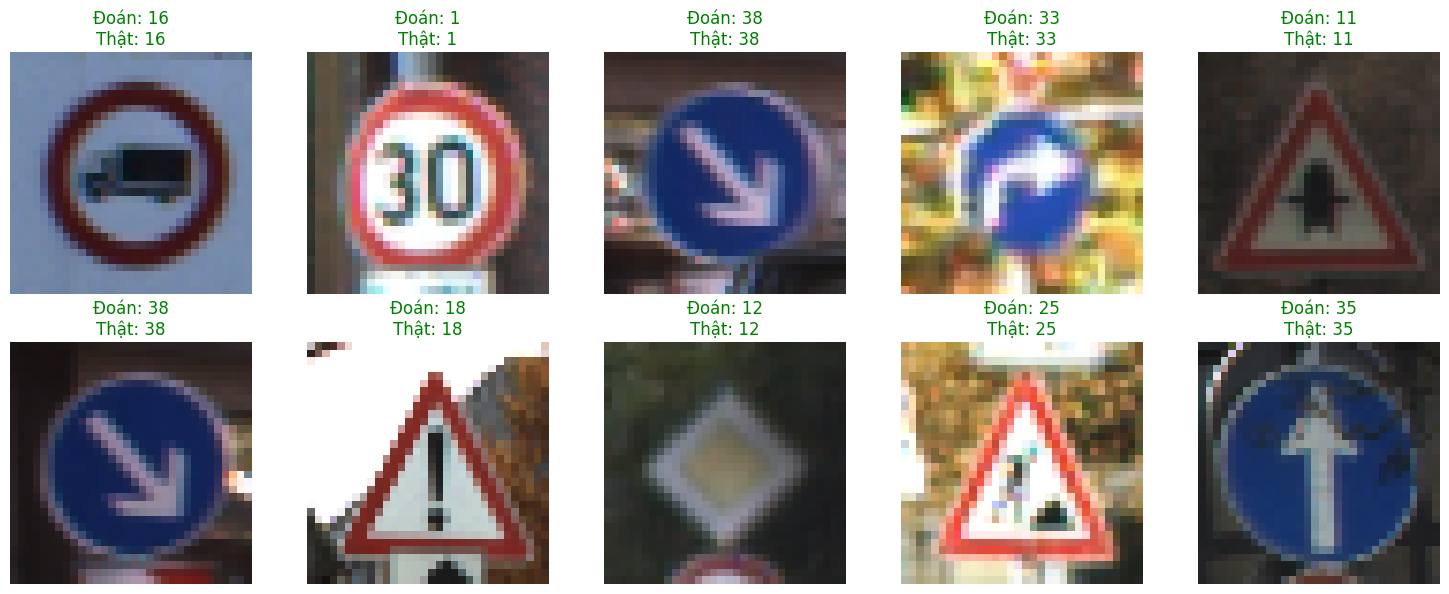


2. SƠ ĐỒ MA TRẬN NHẦM LẪN:


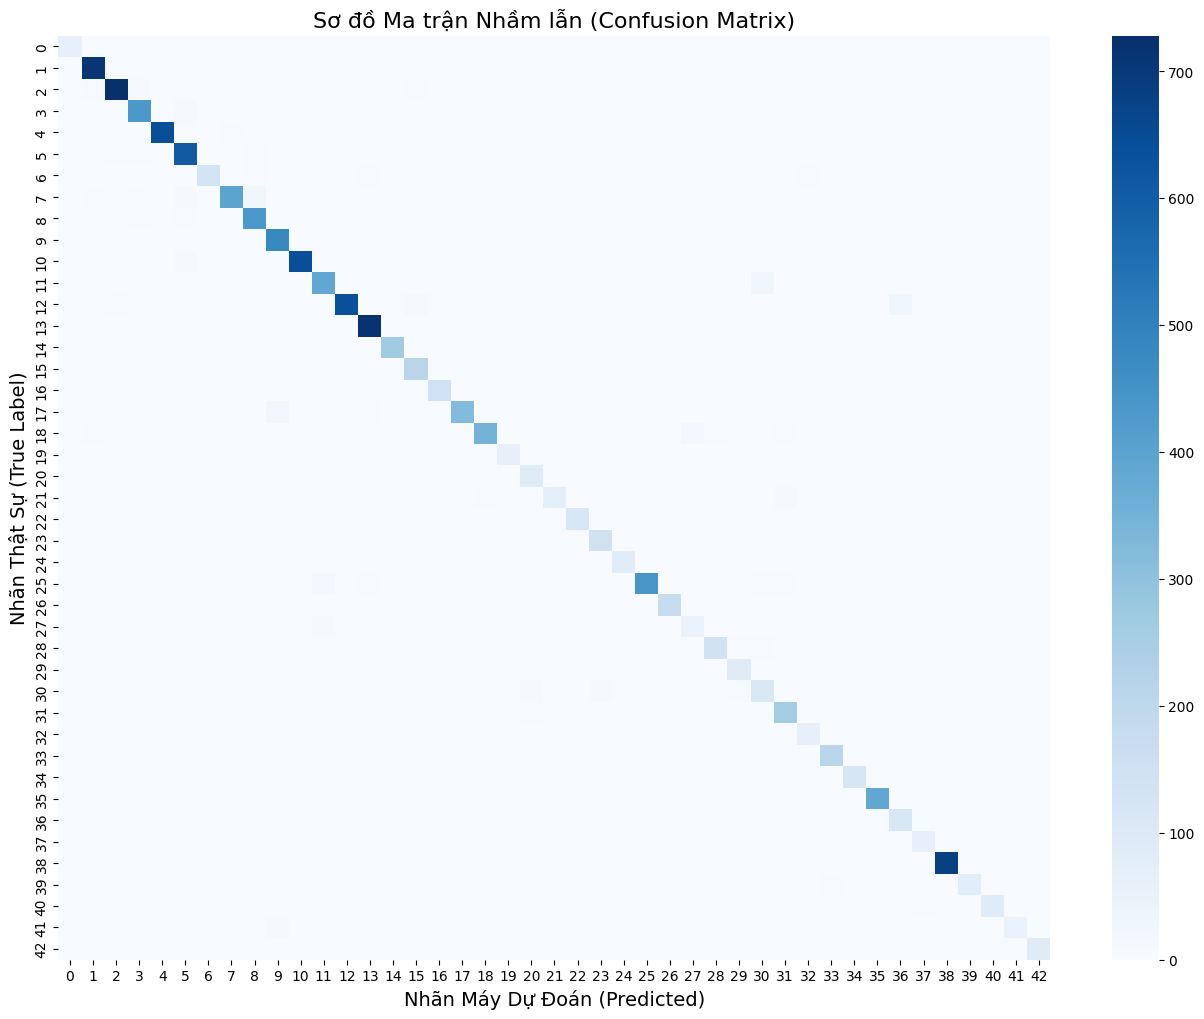

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

print("=== ĐANG VẼ SƠ ĐỒ TRỰC QUAN HÓA... ===")

# 1. Vẽ sơ đồ 10 ảnh dự đoán thực tế
def show_test_predictions(model, test_loader, num_images=10):
    model.eval()
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

    images = images.cpu().numpy()
    labels = labels.cpu().numpy()
    predicted = predicted.cpu().numpy()

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.ravel()

    for i in range(num_images):
        # Đảo ngược chuẩn hóa và đổi CHW về HWC để hiển thị
        img = np.transpose(images[i], (1, 2, 0))

        axes[i].imshow(img)
        # Nếu đoán đúng in màu xanh, đoán sai in màu đỏ
        color = 'green' if predicted[i] == labels[i] else 'red'
        axes[i].set_title(f"Đoán: {predicted[i]}\nThật: {labels[i]}", color=color, fontsize=12)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

print("\n1. SƠ ĐỒ ẢNH DỰ ĐOÁN THỰC TẾ:")
show_test_predictions(model, test_loader)

# 2. Vẽ Ma trận nhầm lẫn (Confusion Matrix)
def plot_confusion_matrix(model, test_loader):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.numpy())
            all_preds.extend(predicted.cpu().numpy())

    # Tính toán ma trận
    cm = confusion_matrix(all_labels, all_preds)

    # Vẽ biểu đồ nhiệt (Heatmap)
    plt.figure(figsize=(16, 12))
    sns.heatmap(cm, annot=False, cmap='Blues', fmt='d')
    plt.title('Sơ đồ Ma trận Nhầm lẫn (Confusion Matrix)', fontsize=16)
    plt.xlabel('Nhãn Máy Dự Đoán (Predicted)', fontsize=14)
    plt.ylabel('Nhãn Thật Sự (True Label)', fontsize=14)
    plt.show()

print("\n2. SƠ ĐỒ MA TRẬN NHẦM LẪN:")
plot_confusion_matrix(model, test_loader)

## 8. Test với ảnh được tải lên

=== 📸 TẢI ẢNH LÊN ĐỂ MÔ HÌNH BÓI THỬ ===
Bấm nút 'Choose Files' bên dưới và chọn 1 bức ảnh biển báo từ máy tính của bạn.


Saving OIP.webp to OIP (1).webp

Đang phân tích ảnh: OIP (1).webp ...


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128073 (\N{WHITE RIGHT POINTING BACKHAND INDEX}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128072 (\N{WHITE LEFT POINTING BACKHAND INDEX}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


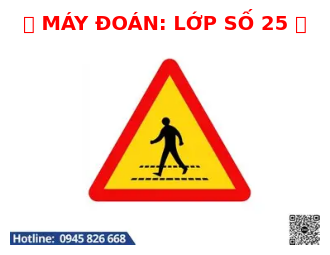

In [ ]:
from google.colab import files
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

print("=== 📸 TẢI ẢNH LÊN ĐỂ MÔ HÌNH ĐOÁN THỬ ===")
print("Bấm nút 'Choose Files' bên dưới và chọn 1 bức ảnh biển báo từ máy tính của bạn.")
uploaded = files.upload()

# Vòng lặp này xử lý nếu bạn lỡ upload nhiều ảnh cùng lúc
for file_name in uploaded.keys():
    print(f"\nĐang phân tích ảnh: {file_name} ...")

    # 1. Đọc ảnh bằng OpenCV
    img = cv2.imread(file_name)
    if img is None:
        print("Lỗi: Không thể đọc được file ảnh này.")
        continue

    # Lưu lại một bản copy nguyên gốc để lát nữa vẽ lên màn hình
    img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Tiền xử lý ảnh (Phải giống y chang lúc Train)
    img_processed = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_processed = cv2.resize(img_processed, (IMG_SIZE, IMG_SIZE))
    img_processed = img_processed.astype(np.float32) / 255.0

    # Chuyển thành Tensor -> Đổi HWC thành CHW -> Thêm chiều Batch (unsqueeze)
    img_tensor = torch.tensor(img_processed, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)

    # Ném ảnh lên GPU
    img_tensor = img_tensor.to(device)

    # 3. Chạy mô hình dự đoán
    model.eval() # Nhớ bật chế độ đi thi
    with torch.no_grad():
        output = model(img_tensor)
        # Tìm class có điểm số cao nhất
        _, predicted = torch.max(output.data, 1)
        class_id = predicted.item()

    # 4. Vẽ ảnh và in kết quả ra màn hình
    plt.figure(figsize=(4, 4))
    plt.imshow(img_display)
    plt.title(f"MÁY ĐOÁN: LỚP SỐ {class_id}", fontsize=14, color='red', fontweight='bold')
    plt.axis('off')
    plt.show()

